In [1]:
# Import libraries
import rasterio as rio
import numpy as np
import matplotlib.pyplot as plt
#from rasterio.windows import Window

In [12]:
# Define data stats
def resp_stats(x):
    
    return {'mean': np.nanmean(x),
            'std': np.nanstd(x),
            'max': np.nanmax(x), 
            'min': np.nanmin(x),
            '25-q': np.nanquantile(x, 0.25),
            '50-q': np.nanquantile(x, 0.50),
            '75-q': np.nanquantile(x, 0.75)}

## Sentinel 1

In [2]:
# Open S1 images

# Original
path_img_01 = 'imgs_org/S1A_IW_GRDH_1SDV_20160905T091437_20160905T091502_012915_0146AC_B51C.tif'
with rio.open(path_img_01) as src_01:
    img_01 = src_01.read() # VH y VV
    
# Calibrated
path_img_02 = 'imgs_calb/S1A_IW_GRDH_1SDV_20160905T091437_20160905T091502_012915_0146AC_B51C_Orb_tnr_Cal.tif'
with rio.open(path_img_02) as src_02:
    img_02 = src_02.read() # VH y VV


/home/franco-barrionuevo/miniconda3/envs/sar_maie/lib/python3.14/site-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


In [5]:
'''# Subset original
subs_s1_VH_org = img_01[0, int(16887/3):int(16887-16887/3), int(26384/3):int(26384-26384/3)]
subs_s1_VV_org = img_01[1, int(16887/3):int(16887-16887/3), int(26384/3):int(26384-26384/3)]

# Subset calibrado
subs_s1_VH_cal = img_02[0, int(16887/3):int(16887-16887/3), int(26384/3):int(26384-26384/3)]
subs_s1_VV_cal = img_02[1, int(16887/3):int(16887-16887/3), int(26384/3):int(26384-26384/3)]'''

# Subset original
subs_s1_VH_org = img_01[0, int(5000):int(6000), int(20000):int(21000)]
subs_s1_VV_org = img_01[1, int(5000):int(6000), int(20000):int(21000)]

# Subset calibrado
subs_s1_VH_cal = img_02[0, int(5000):int(6000), int(20000):int(21000)]
subs_s1_VV_cal = img_02[1, int(5000):int(6000), int(20000):int(21000)]

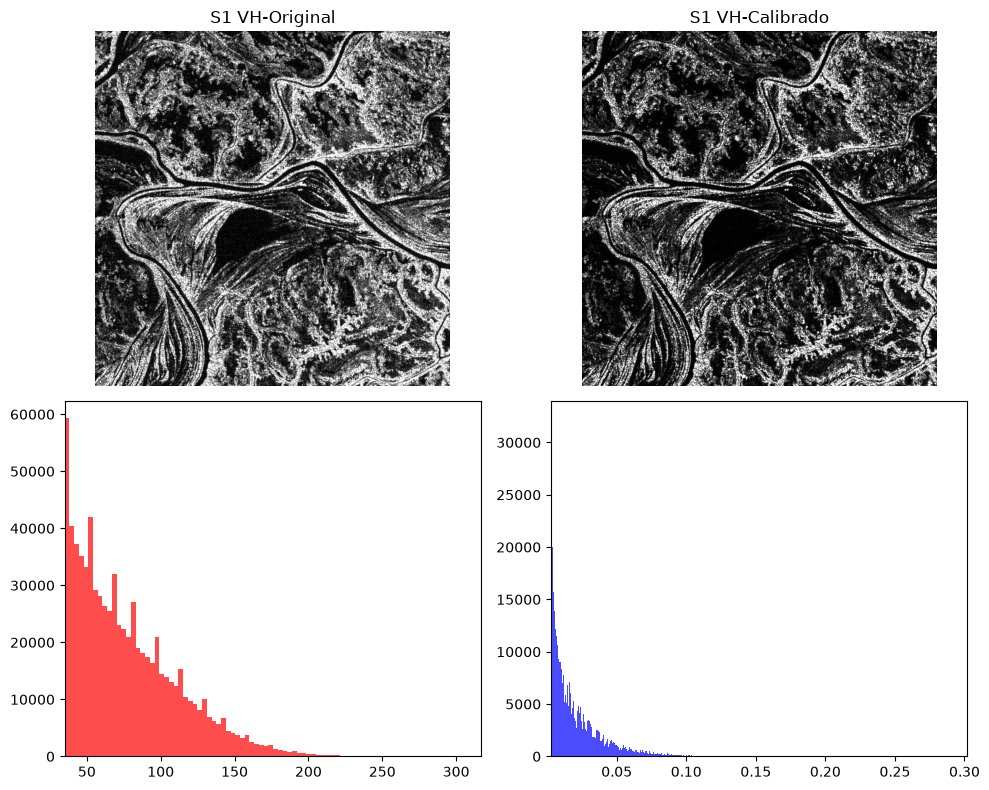

In [13]:
# Plot data and histograms
fig, ax = plt.subplots(2, 2, figsize=(10, 8), tight_layout=True)

# Plot images
ax[0, 0].imshow(subs_s1_VH_org, cmap='gray', vmin = np.nanpercentile(subs_s1_VH_org, 5), vmax=np.nanpercentile(subs_s1_VH_org, 95))
ax[0, 0].set_axis_off()
ax[0, 0].set_title('S1 VH-Original')

ax[0, 1].imshow(subs_s1_VH_cal, cmap='gray', vmin = np.nanpercentile(subs_s1_VH_cal, 5), vmax=np.nanpercentile(subs_s1_VH_cal, 95))
ax[0, 1].set_axis_off()
ax[0, 1].set_title('S1 VH-Calibrado')

# Plot histograms
ax[1, 0].hist(subs_s1_VH_org.ravel(), bins=100, color='red', alpha=0.7)
ax[1, 0].set_xlim(left=np.nanpercentile(subs_s1_VV_org, 1), right=np.nanpercentile(subs_s1_VV_org, 99)) # Sets max X-axis value to p-99, 
ax[1, 0].tick_params(labelsize=10)

ax[1, 1].hist(subs_s1_VH_cal.ravel(), bins=1000, color='blue', alpha=0.7)
ax[1, 1].set_xlim(left=np.nanpercentile(subs_s1_VV_cal, 1), right=np.nanpercentile(subs_s1_VV_cal, 99)) # Sets max X-axis value to p-99, 
ax[1, 1].tick_params(labelsize=10)

In [ ]:
# Prints stats subset
print('S1 VH-Original', resp_stats(subs_s1_VH_org))
print('S1 VH-Calibrada', resp_stats(subs_s1_VH_cal))


S1 VH-Original {'mean': np.float64(64.859419), 'std': np.float64(37.39242789633269), 'max': np.uint16(327), 'min': np.uint16(6), '25-q': np.float64(35.0), '50-q': np.float64(55.0), '75-q': np.float64(87.0)}
S1 VH-Calibrada {'mean': np.float32(0.015919274), 'std': np.float32(0.019750008), 'max': np.float32(0.32047814), 'min': np.float32(-0.00089815416), '25-q': np.float32(0.0026964352), '50-q': np.float32(0.008221781), '75-q': np.float32(0.021886244)}


In [16]:
# Print stats whole image
print('S1 VH-Original', resp_stats(img_01[0]))
print('S1 VH-Calibrada', resp_stats(img_02[0]))

S1 VH-Original {'mean': np.float64(85.00817160973651), 'std': np.float64(47.16735729197496), 'max': np.uint16(15094), 'min': np.uint16(0), '25-q': np.float64(54.0), '50-q': np.float64(81.0), '75-q': np.float64(112.0)}
S1 VH-Calibrada {'mean': np.float32(0.022770565), 'std': np.float32(0.1390449), 'max': np.float32(519.47144), 'min': np.float32(-0.0053312373), '25-q': np.float32(0.0063019027), '50-q': np.float32(0.016365312), '75-q': np.float32(0.030817688)}


## Cosmo Skymed

In [18]:
# Open Cosmo Skymed images

# Original
path_img_03 = 'imgs_org/CSKS1_DGM_B_PP_13_CO_LA_SF_20100910095636_20100910095642.tif'
with rio.open(path_img_03) as src_03:
    img_03 = src_03.read() # VV y HH
    
# Calibrated
path_img_04 = 'imgs_calb/CSKS1_DGM_B_PP_13_CO_LA_SF_20100910095636_20100910095642_Cal.tif'
with rio.open(path_img_04) as src_04:
    img_04 = src_04.read() # VV y HH

/home/franco-barrionuevo/miniconda3/envs/sar_maie/lib/python3.14/site-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


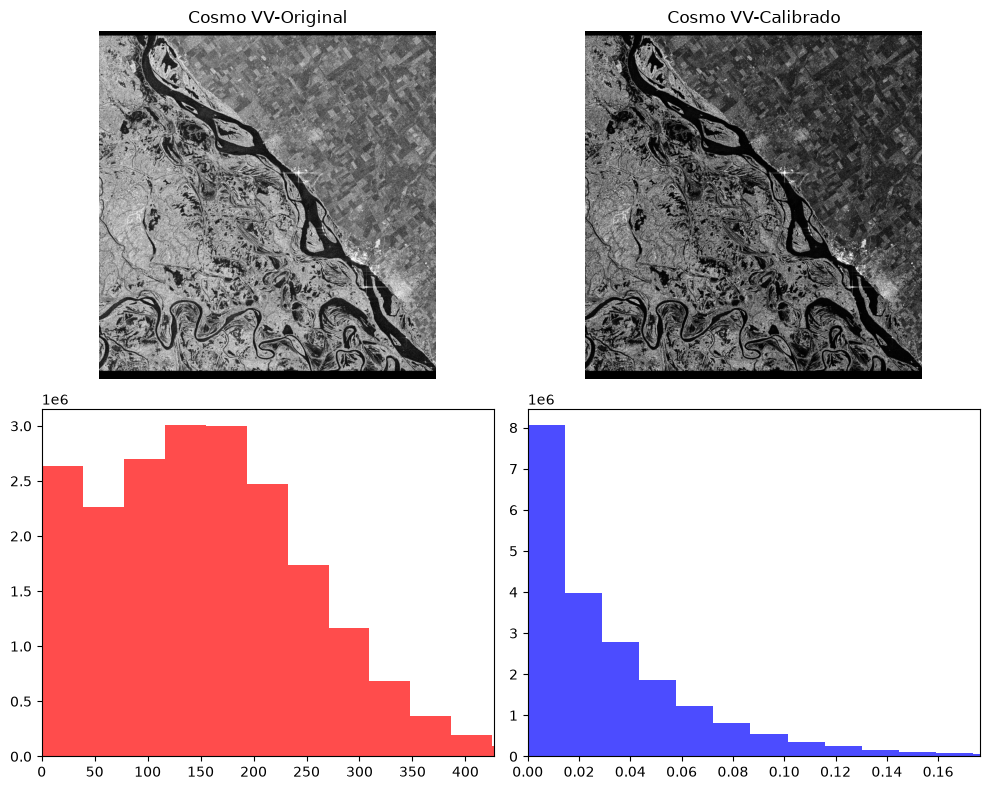

In [19]:
# Plot data and histograms
fig, ax = plt.subplots(2, 2, figsize=(10, 8), tight_layout=True)

# --
ax[0, 0].imshow(img_03[0], cmap='gray', vmin = np.nanpercentile(img_03[0], 5), vmax=np.nanpercentile(img_03[0], 95))
ax[0, 0].set_axis_off()
ax[0, 0].set_title('Cosmo VV-Original')

ax[0, 1].imshow(img_04[0], cmap='gray', vmin = np.nanpercentile(img_04[0], 5), vmax=np.nanpercentile(img_04[0], 95))
ax[0, 1].set_axis_off()
ax[0, 1].set_title('Cosmo VV-Calibrado')

# --
ax[1, 0].hist(img_03[0].ravel(), bins=1000, color='red', alpha=0.7)
ax[1, 0].set_xlim(left=np.nanpercentile(img_03[0], 1), right=np.nanpercentile(img_03[0], 99)) # Sets max X-axis value to p-99, 
ax[1, 0].tick_params(labelsize=10)

ax[1, 1].hist(img_04[0].ravel(), bins=100000, color='blue', alpha=0.7)
ax[1, 1].set_xlim(left=np.nanpercentile(img_04[0], 1), right=np.nanpercentile(img_04[0], 99)) # Sets max X-axis value to p-99, 
ax[1, 1].tick_params(labelsize=10)

In [20]:
# Prints stats subset
print('Cosmo VV-Original', resp_stats(img_03[0]))
print('Cosmo VV-Calibrada', resp_stats(img_04[0]))

Cosmo VV-Original {'mean': np.float32(156.85048), 'std': np.float32(121.01545), 'max': np.float32(38680.0), 'min': np.float32(0.0), '25-q': np.float32(81.0), '50-q': np.float32(150.0), '75-q': np.float32(219.0)}
Cosmo VV-Calibrada {'mean': np.float32(0.03795066), 'std': np.float32(1.1747426), 'max': np.float32(1446.7313), 'min': np.float32(0.0), '25-q': np.float32(0.006344319), '50-q': np.float32(0.021756923), '75-q': np.float32(0.04637706)}
